# NHANES Dataset Analysis: Female Participants - Waist Circumference Prediction using kNN

## Overview

This notebook presents a gender-specific analysis of the **National Health and Nutrition Examination Survey (NHANES)** dataset, focusing exclusively on **female participants**. The analysis compares diabetic vs. non-diabetic females to identify disease and gender-specific patterns in waist circumference prediction.

### Dataset Information

- **Source**: [NHANES CDC Database](https://wwwn.cdc.gov/nchs/nhanes/)
- **Focus**: Female participants only (RIAGENDR == 2), stratified by diabetes status
- **Objective**: Identify relevant features for conditional mean and variance in waist circumference prediction for females
- **Preprocessing**: Unnecessary variables and missing data have been removed (see data directory)

---

## Methodology

### 1. Data Preprocessing

**Dual Filtering**:
- **Gender filter**: Only female participants (RIAGENDR == 2)
- **Diabetes stratification**: Non-diabetic (diabetes == 0) vs. Diabetic (diabetes == 1)
- Each group analyzed separately to identify disease-specific predictors in females
- Train-test split (50/50) for cross-validation

**Independent variables (X)**:
- **RIDAGEYR**: Age (years)
- **BMXHT**: Height (cm)
- **BMXWT**: Weight (kg)
- **BMXBMI**: Body Mass Index
- **BPXDI1**: Diastolic blood pressure
- **BPXSY1**: Systolic blood pressure
- **BPXPLS**: Pulse rate
- **LBDSCHSI**: Total cholesterol (SI units)
- **LBXSTR**: Triglycerides
- **LBXSGL**: Glucose (serum)
- **LBXGH**: Glycohemoglobin (%)

**Dependent variable (Y)**:
- **BMXWAIST**: Waist circumference (cm)

### 2. kNN Model Configuration

Dual modeling approach for each female subgroup (diabetic/non-diabetic):

1. **Conditional mean model**: Predicts expected waist circumference
2. **Conditional variance model**: Predicts variability in waist circumference

**Hyperparameters**:
- Search grid for k: [5, 10, 20, 50, 100, 200, 500, 1000, 2000]
- Separate grids for mean (`grida`) and variance (`gridv`)
- Automatic feature selection with statistical significance testing

### 3. ROC Analysis

**Conditional ROC Curves for Females**:
- Compare predictions from non-diabetic vs. diabetic female models
- Compute Area Under the Curve (AUC) for each female participant
- Analyze gender-specific discrimination patterns

**Research Question**: Do diabetic vs. non-diabetic patterns differ in females compared to males and the general population?

### 4. Visualization

3D scatter plot showing:
- **Weight vs. BMI vs. AUC** (female participants only)
- Demonstrates discrimination ability across anthropometric variables in females
- Color gradient (viridis) indicates AUC values

---

## Expected Results

1. **Female-specific features**: Identify which variables are most relevant for waist circumference in females
2. **Disease patterns in females**: Understand how diabetes affects waist circumference differently in females
3. **Variance predictors**: Identify factors that increase variability specifically in female populations
4. **Gender comparison**: Enable comparison with male-only and unified analyses to reveal sex differences

---

## Technical Notes

- **Reproducibility**: Fixed seeds for numpy and random
- **Data type**: float32 for computational efficiency
- **Sample size**: Female subset only, further split by diabetes status
- **ROC calculation**: Computed for first 1000 female participants in test set

In [1]:
# Import required libraries

import sys
sys.path.append("../..")  # Add path to import knnvs module

# Standard libraries
import math
import random
import logging

# Data analysis libraries
import numpy as np
import pandas as pd

# Machine learning libraries
import sklearn.metrics as skl
from sklearn.model_selection import train_test_split

# knnvs module (custom kNN implementation)
from knnvs import KnnBag, KnnVar, initialize_knn, roc

# Visualization libraries
import matplotlib.pyplot as plt
import matplotlib as mpl

# Configure visualization parameters
mpl.rcParams['axes.labelsize'] = 9  # Axis label size

## Data Loading and Preparation

In this section we load the NHANES dataset and apply **dual filtering**:
1. Filter for **female participants only** (RIAGENDR == 2)
2. Stratify by **diabetes status** (0 = non-diabetic, 1 = diabetic)

**Selected variables**:
- **Independent (X)**: age, height, weight, BMI, blood pressure (systolic/diastolic), pulse rate, cholesterol, triglycerides, glucose, glycohemoglobin
- **Dependent (Y)**: waist circumference (BMXWAIST, in cm)

**Important**: The same variable set is used for both diabetic and non-diabetic females to enable direct comparison within the female population and across gender groups.

In [2]:
# Set seeds for reproducibility
random.seed(1)
np.random.seed(1)

# Grids for hyperparameter k search
# grida: k values for conditional mean model
# gridv: k values for conditional variance model
grida = np.array([5, 10, 20, 50, 100, 200, 500, 1000, 2000])
gridv = np.array([5, 10, 20, 50, 100, 200, 500, 1000, 2000])

# Load dataset
df = pd.read_csv('data/nhanes20220129.csv')

# Apply dual filtering: FEMALE participants + diabetes stratification
# RIAGENDR == 2: Female
# diabetes == 0: Non-diabetic
# diabetes == 1: Diabetic
df0 = df.loc[(df['RIAGENDR'] == 2) & (df['diabetes'] == 0)]  # Non-diabetic females
df1 = df.loc[(df['RIAGENDR'] == 2) & (df['diabetes'] == 1)]  # Diabetic females

# Define dependent and independent variables
out = 'BMXWAIST'  # Target variable: waist circumference (cm)
inp = np.array([
    "RIDAGEYR",   # Age (years)
    "BMXHT",      # Height (cm)
    "BMXWT",      # Weight (kg)
    "BMXBMI",     # Body Mass Index
    "BPXDI1",     # Diastolic blood pressure
    "BPXSY1",     # Systolic blood pressure
    "BPXPLS",     # Pulse rate
    "LBDSCHSI",   # Total cholesterol (SI units)
    "LBXSTR",     # Triglycerides
    "LBXSGL",     # Glucose (serum)
    "LBXGH"       # Glycohemoglobin (%)
])

# Extract arrays for non-diabetic females
y0 = df0[out].to_numpy().astype('float32')
x0 = df0[inp].to_numpy().astype('float32')

# Extract arrays for diabetic females
y1 = df1[out].to_numpy().astype('float32')
x1 = df1[inp].to_numpy().astype('float32')

# Split each female group into train/test (50/50 split)
# Non-diabetic females: x01/y01 for training, x02/y02 for testing
x01, x02, y01, y02 = train_test_split(x0, y0, test_size=0.50, random_state=11)

# Diabetic females: x11/y11 for training, x12/y12 for testing
x11, x12, y11, y12 = train_test_split(x1, y1, test_size=0.50, random_state=11)

print(f'Non-diabetic female participants: {len(y0)} total ({len(y01)} train, {len(y02)} test)')
print(f'Diabetic female participants: {len(y1)} total ({len(y11)} train, {len(y12)} test)')

Non-diabetic female participants: 26089 total (13044 train, 13045 test)
Diabetic female participants: 4444 total (2222 train, 2222 test)


## kNN Model Initialization and Training - Non-Diabetic Female Participants

The `initialize_knn` function performs feature selection and model training for **non-diabetic female participants**.

**Process**:
1. **Feature selection**: Identifies the most relevant variables for non-diabetic females through statistical tests
2. **Cross-validation**: Finds the optimal k value for each model
3. **Training**: Fits both conditional mean and variance models

**Parameters**:
- `x01`, `y01`: Training data (non-diabetic female participants only)
- `grida`, `gridv`: Search grids for k (mean and variance)
- `quantile`: Threshold for feature selection (1 - α = 0.99)

**Returns**:
- `knna0`: kNN model for conditional mean
- `fa0`: Indices of selected features for mean
- `ka0`: Optimal k value for mean
- `pva0`: P-values of features (mean)
- `knnv0`: kNN model for conditional variance
- `fv0`: Indices of selected features for variance
- `kv0`: Optimal k value for variance
- `pvv0`: P-values of features (variance)

**Expected gender difference**: Females may show different variance predictors compared to males (e.g., triglycerides may be more significant in females).

In [3]:
# Initialize and train kNN models for NON-DIABETIC FEMALE participants
knna0, fa0, ka0, pva0, knnv0, fv0, kv0, pvv0 = initialize_knn(
    x01, y01, 
    grida, gridv, 
    quantile=(1 - 0.01)  # 99% confidence level
)

# Create combined model including both mean and variance
knn0 = KnnVar(knna0, knnv0)

# Display selected features for non-diabetic female participants
print('Non-diabetic female participants - selected features for mean:\n  {}'.format(inp[fa0]))
print('Non-diabetic female participants - selected features for variance:\n  {}'.format(inp[fv0]))
print(f'\nOptimal k value for mean: {ka0}')
print(f'Optimal k value for variance: {kv0}')

# Highlight if triglycerides (LBXSTR) is selected - a potential gender-specific marker
if 'LBXSTR' in inp[fv0]:
    print('\nNote: Triglycerides selected for variance (potentially gender-specific)')

Non-diabetic female participants - selected features for mean:
  ['BMXWT' 'BMXBMI']
Non-diabetic female participants - selected features for variance:
  ['BMXWT' 'LBXSTR']

Optimal k value for mean: 100
Optimal k value for variance: 1000

Note: Triglycerides selected for variance (potentially gender-specific)


## kNN Model Initialization and Training - Diabetic Female Participants

Now we train a separate model for **diabetic female participants** to identify disease-specific patterns within the female population.

**Expected differences from non-diabetic females**:
- Different features may be selected for the mean model
- Variance model may show increased complexity due to metabolic dysregulation
- Optimal k values may differ due to different data distributions

**Gender comparison**: Compare with diabetic male results to identify sex-specific responses to diabetes.

In [4]:
# Initialize and train kNN models for DIABETIC FEMALE participants
knna1, fa1, ka1, pva1, knnv1, fv1, kv1, pvv1 = initialize_knn(
    x11, y11, 
    grida, gridv, 
    quantile=(1 - 0.01)  # 99% confidence level
)

# Create combined model including both mean and variance
knn1 = KnnVar(knna1, knnv1)

# Display selected features for diabetic female participants
print('Diabetic female participants - selected features for mean:\n  {}'.format(inp[fa1]))
print('Diabetic female participants - selected features for variance:\n  {}'.format(inp[fv1]))
print(f'\nOptimal k value for mean: {ka1}')
print(f'Optimal k value for variance: {kv1}')

# Compare mean predictors between non-diabetic and diabetic females
print('\n--- COMPARISON WITHIN FEMALES ---')
print('Both groups selected for MEAN:', set(inp[fa0]) & set(inp[fa1]))
print('Only non-diabetic for MEAN:', set(inp[fa0]) - set(inp[fa1]))
print('Only diabetic for MEAN:', set(inp[fa1]) - set(inp[fa0]))
print('\nVariance features unique to non-diabetic females:', set(inp[fv0]) - set(inp[fv1]))
print('Variance features unique to diabetic females:', set(inp[fv1]) - set(inp[fv0]))

No features passed significance test at quantile=0.99. Using all 11 features.


Diabetic female participants - selected features for mean:
  ['BMXWT']
Diabetic female participants - selected features for variance:
  ['RIDAGEYR' 'BMXHT' 'BMXWT' 'BMXBMI' 'BPXDI1' 'BPXSY1' 'BPXPLS' 'LBDSCHSI'
 'LBXSTR' 'LBXSGL' 'LBXGH']

Optimal k value for mean: 20
Optimal k value for variance: 50

--- COMPARISON WITHIN FEMALES ---
Both groups selected for MEAN: {'BMXWT'}
Only non-diabetic for MEAN: {'BMXBMI'}
Only diabetic for MEAN: set()

Variance features unique to non-diabetic females: set()
Variance features unique to diabetic females: {'BPXPLS', 'LBXSGL', 'LBDSCHSI', 'BMXBMI', 'BPXDI1', 'BPXSY1', 'RIDAGEYR', 'BMXHT', 'LBXGH'}


## ROC Analysis: Model Discrimination in Female Participants

In this section we assess how well the two models (non-diabetic vs. diabetic females) can discriminate between female participants with different diabetes status.

**Methodology**:
1. **Combine test sets**: Concatenate non-diabetic and diabetic female test data
2. **Dual predictions**: Use both models to predict waist circumference for all female participants
3. **Residual calculation**: Compute prediction errors for each model
4. **Conditional ROC**: Calculate Area Under the Curve (AUC) for each female participant

**ROC Parameters**:
- **a = (mean_1 - mean_0) / std_1**: Normalized mean difference between models
- **b = std_0 / std_1**: Ratio of standard deviations between models
- **res_0, res_1**: Residuals from non-diabetic and diabetic models

**Interpretation**:
- **High AUC (close to 1)**: Strong discrimination between diabetic and non-diabetic patterns in females
- **Low AUC (close to 0.5)**: Poor discrimination (similar patterns regardless of diabetes status)
- AUC varies by female participant characteristics (weight, BMI, age, etc.)

**Gender-specific insight**: This analysis reveals whether diabetes affects waist circumference patterns differently in females compared to males. Expected differences may include:
- Different AUC distributions
- Different body type dependencies
- Potentially stronger/weaker discrimination in certain anthropometric profiles

In [5]:
# Combine test sets from both female groups
y2 = np.concatenate((y02, y12), axis=0)  # True waist circumference values
x2 = np.concatenate((x02, x12), axis=0)  # Feature vectors

# Generate predictions using BOTH models for ALL female test participants
# Non-diabetic female model predictions
mean_0 = knn0.predict_average(x2, k=ka0)           # Conditional mean
std_0 = np.sqrt(knn0.predict_variance(x2, k=kv0))  # Standard deviation
res_0 = y2 - mean_0                                 # Residuals

# Diabetic female model predictions
mean_1 = knn1.predict_average(x2, k=ka1)           # Conditional mean
std_1 = np.sqrt(knn1.predict_variance(x2, k=kv1))  # Standard deviation
res_1 = y2 - mean_1                                 # Residuals

# Double-check variance predictions (for debugging)
knn1.predict_variance(x2, k=kv1)

# Calculate ROC parameters
a = (mean_1 - mean_0) / std_1  # Normalized difference in means
b = std_0 / std_1              # Ratio of standard deviations

# Compute AUC for first 1000 female participants
areas = []
for i in range(1000):
    # ROC function computes area under the curve based on:
    # - a[i]: mean difference parameter
    # - b[i]: variance ratio parameter
    # - -res_0, -res_1: negated residuals (for correct orientation)
    area = roc(a[i], b[i], -res_0, -res_1)
    areas.append(area)

print(f'Computed AUC for {len(areas)} female participants')
print(f'Mean AUC: {np.mean(areas):.3f}')
print(f'Std AUC: {np.std(areas):.3f}')
print(f'Min AUC: {np.min(areas):.3f}, Max AUC: {np.max(areas):.3f}')
print(f'\nNote: Compare these statistics with male participants (nhanes_2.ipynb) to identify gender differences')

Computed AUC for 1000 female participants
Mean AUC: 0.738
Std AUC: 0.017
Min AUC: 0.672, Max AUC: 0.789

Note: Compare these statistics with male participants (nhanes_2.ipynb) to identify gender differences


### Visualization: AUC Across Anthropometric Variables (Female Participants)

This 3D scatter plot visualizes the Area Under the Curve as a function of weight and BMI **for female participants only**.

**Interpretation**:
- **Color gradient**: Represents AUC values (viridis colormap)
- **High AUC regions**: Female body types where models strongly discriminate between diabetic/non-diabetic
- **Low AUC regions**: Female characteristics where discrimination is weak
- **Gender-specific patterns**: Compare with male analysis (nhanes_2.ipynb) to identify sex differences

**Key Insights**:
1. This visualization reveals for which female body types (weight/BMI combinations) the diabetic vs. non-diabetic distinction is most pronounced in waist circumference patterns
2. Females may show different patterns compared to males due to:
   - Different body fat distribution (gynoid vs. android)
   - Hormonal influences on metabolism
   - Different variance predictors (e.g., triglycerides more important in females)

**Research question**: Do females show different discrimination patterns compared to males? Are certain BMI ranges more discriminative in one gender vs. the other?

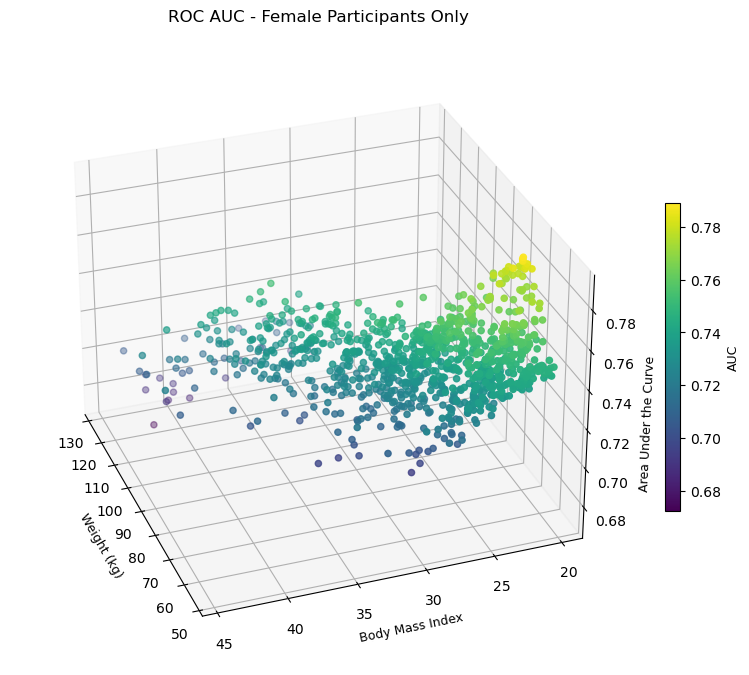

Plot saved as nhanes_3_roc.png

For gender comparison, compare this plot with:
  - nhanes_2_roc.png (Male participants)
  - nhanes_1_roc.png (All participants)


In [6]:
# Create figure for 3D plot of AUC vs Weight and BMI (females only)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 3D scatter plot with colormap
# x2[:1000, 2] = Weight (index 2 in feature array)
# x2[:1000, 3] = BMI (index 3 in feature array)
# areas = AUC values for first 1000 female participants
scatter = ax.scatter(
    x2[:1000, 2],     # X-axis: Weight (kg)
    x2[:1000, 3],     # Y-axis: Body Mass Index
    areas,            # Z-axis: Area Under the Curve
    c=areas,          # Color by AUC value
    cmap='viridis',   # Colormap
    s=20              # Point size
)

# Configure labels and visualization
ax.set_xlabel('Weight (kg)')
ax.set_ylabel('Body Mass Index')
ax.set_zlabel('Area Under the Curve')
ax.grid(True)
ax.set_facecolor('white')  # White background
ax.view_init(elev=30, azim=160)  # Viewing angle

# Add colorbar
plt.colorbar(scatter, ax=ax, label='AUC', shrink=0.5)

# Add title indicating female-specific analysis
ax.set_title('ROC AUC - Female Participants Only', pad=20)

# Save figure
plt.savefig('nhanes_3_roc.png', bbox_inches='tight', pad_inches=0, dpi=150)
plt.show()

print('Plot saved as nhanes_3_roc.png')
print('\nFor gender comparison, compare this plot with:')
print('  - nhanes_2_roc.png (Male participants)')
print('  - nhanes_1_roc.png (All participants)')

## Summary and Gender Comparison

This notebook completes the gender-stratified analysis of the NHANES dataset. 

**Key Findings to Compare Across Notebooks**:

1. **Feature Selection**:
   - Compare which features are selected for females vs. males
   - Identify gender-specific predictors (e.g., triglycerides in variance)

2. **Discrimination Power**:
   - Compare mean AUC values between genders
   - Identify which gender shows stronger diabetic vs. non-diabetic discrimination

3. **Body Type Dependencies**:
   - Examine if high/low AUC regions differ by gender
   - Understand if certain BMI ranges are more informative in one gender

4. **Variance Patterns**:
   - Compare variance predictors: males may rely more on all features, females on specific markers like triglycerides

**Next Steps**:
- Cross-reference findings with nhanes_1.ipynb (unified analysis) and nhanes_2.ipynb (male analysis)
- Consider clinical implications of gender differences in diabetes-related waist circumference patterns